<h2 style="color:blue;text-align:center;">Task 2: Customer Segmentation Analysis</h2>

<h3 style="color:purple">Step 1: Load Dataset</h3>
Load the customer dataset and check its basic structure,columns and data.

In [2]:
import pandas as pd
df=pd.read_csv("Online_Retail.csv")
print("Dataset shape:",df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\n Duplicate rows:",df.duplicated().sum())
df=df.dropna(subset=["CustomerID"])
df=df.drop_duplicates()
df=df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df=df[(df["Quantity"]>0)&(df["UnitPrice"]>0)]
print("\nCleaned dataset shape:",df.shape)



Dataset shape: (541909, 8)

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

 Duplicate rows: 5268

Cleaned dataset shape: (392692, 8)


<h3 style="color:purple">Step 2: Descriptive Statistics</h3>

Calculate key customer purchasing measures to understand customer behaviour.

In [3]:
df["TotalPurchase"]=df["Quantity"]*df["UnitPrice"]
average_purchase_value=df["TotalPurchase"].mean()
purchase_frequency=df["InvoiceNo"].nunique()
customer_lifetime_value=(df.groupby("CustomerID")["TotalPurchase"].sum().mean())
print("Average Purchase Value:",round(average_purchase_value,2))
print("Purchase Frequency:",purchase_frequency)
print("Customer Lifetime Value:",customer_lifetime_value)

Average Purchase Value: 22.63
Purchase Frequency: 18532
Customer Lifetime Value: 2048.688080682342


<h3 style="color:purple">Step 3: Feature Selection:RFM Analysis</h3>

Select key customer behaviour features-Recency,Frequency and Monetary-for clustering.

In [4]:
df["InvoiceDate"]=pd.to_datetime(df["InvoiceDate"])
reference_date=df["InvoiceDate"].max()+pd.Timedelta(days=1)
rfm=df.groupby("CustomerID").agg({"InvoiceDate":lambda x:(reference_date-x.max()).days,
"InvoiceNo":"nunique",
"TotalPurchase":"sum"
})
rfm.columns=["Recency","Frequency","Monetary"]
print("RFM Features:")
print(rfm.head())
print("\nRFM shape:",rfm.shape)

RFM Features:
            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40

RFM shape: (4338, 3)


<h3 style="color:purple">Step 4: Data Normalization</h3>

Standardise the RFM features using StandardScaler so all features have a similar scale before clutering.

In [5]:
from sklearn.preprocessing import StandardScaler
rfm_features=rfm[["Recency","Frequency","Monetary"]]
scaler=StandardScaler()
rfm_scaled=scaler.fit_transform(rfm_features)
print("Standardised RFM data:")
print(rfm_scaled[:5])

Standardised RFM data:
[[ 2.33457414 -0.4250965   8.36301037]
 [-0.90534032  0.3544168   0.2516989 ]
 [-0.17535959 -0.03533985 -0.02798783]
 [-0.73534481 -0.4250965  -0.03240559]
 [ 2.17457836 -0.4250965  -0.19081155]]


<h3 style="color:purple">Step 5: Elbow Method</h3>

Use Elbow Method to identify the optimal number of clusters for K-Means.

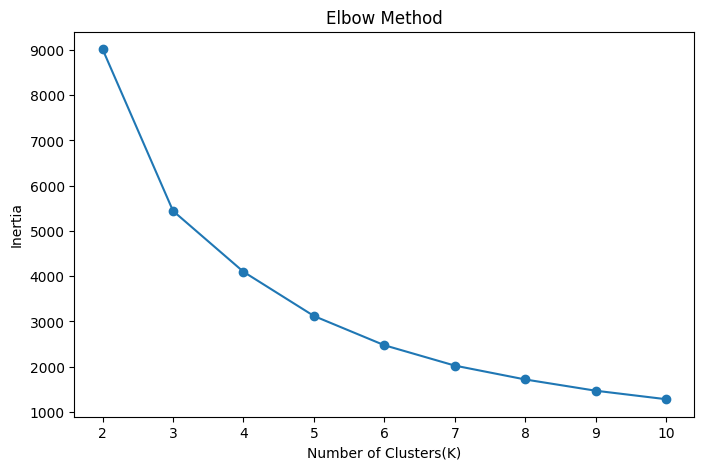

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

k_values=range(2,11)
inertia=[
    KMeans(n_clusters=k,random_state=42,n_init=10)
    .fit(rfm_scaled)
    .inertia_
    for k in k_values]

plt.figure(figsize=(8,5))
plt.plot(k_values,inertia,marker="o")
plt.xlabel("Number of Clusters(K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(k_values)
plt.show()




<h3 style="color:purple"> K-Means Clustering</h3>

Apply K-Meanss with the selected number of clusters to group customers based on their RFM behaviour.

In [7]:
from sklearn.cluster import  KMeans
kmeans=KMeans(n_clusters=4,random_state=42,n_init=10,max_iter=100)
rfm["Cluster"]=kmeans.fit_predict(rfm_scaled)
print("Cluster assignment completed")
print("\n Number of customerss in each cluster:\n")
print(rfm["Cluster"].value_counts().sort_index())

Cluster assignment completed

 Number of customerss in each cluster:

Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


<h3 style="color:purple">Step 6:Visualise Clusters </h3>

Graph 1: Recency vs Frequency
Shows how recently customers purchased and how frequently they  purchase.It helps compare customer activity levels across clusters.

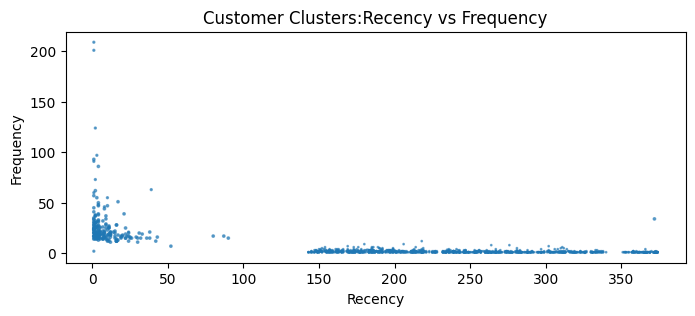

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,3))
plt.scatter(rfm["Recency"],rfm["Frequency"],rfm["Cluster"],alpha=0.6)
plt.xlabel("Recency")
plt.ylabel("Frequency")
plt.title("Customer Clusters:Recency vs Frequency")
plt.show()

Graph 2: Frequency vs Monetary

Shows the relationship between purchase frequency and total spending.It helps identify customers who purchase frequently and contribute higher revenue.

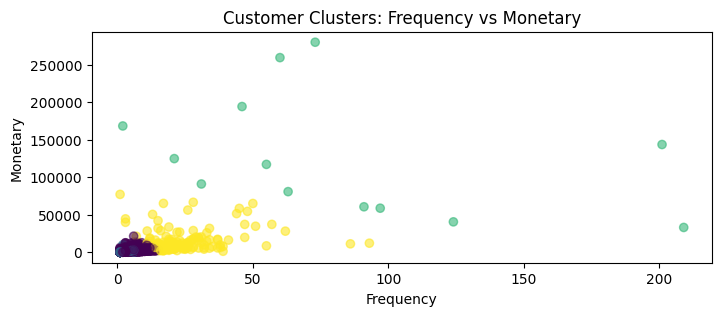

In [9]:
plt.figure(figsize=(8,3))
plt.scatter(rfm["Frequency"],rfm["Monetary"],c=rfm["Cluster"],alpha=0.6)
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Customer Clusters: Frequency vs Monetary")
plt.show()

<h3 style="color:purple">Step 7: Profile Each Cluster</h3>

Calculate the average Recency,Frequency and Monetary values for each cluster to understand the characteristics of different customer segments.

In [10]:
cluster_profile=rfm.groupby("Cluster")[["Recency","Frequency","Monetary"]].mean()
print("Cluster profile:")
print(cluster_profile.round(2))

Cluster profile:
         Recency  Frequency   Monetary
Cluster                               
0          43.70       3.68    1353.63
1         248.08       1.55     478.85
2           7.38      82.54  127187.96
3          15.50      22.33   12690.50


<h3 style="color:purple">Step 8: Number of Customers per Cluster</h3>

Create a bar chart to compare the number of customers in each clusters.

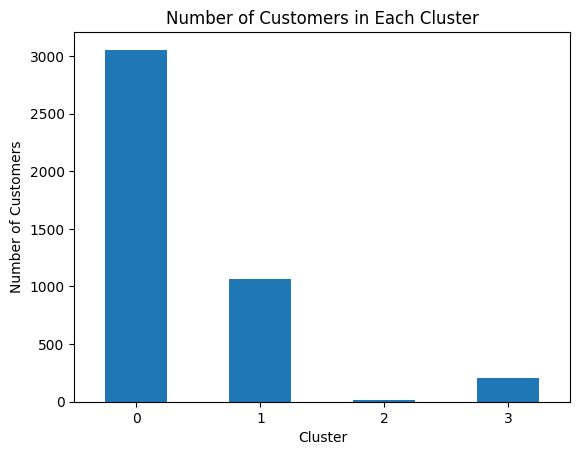

In [11]:
cluster_counts=rfm["Cluster"].value_counts().sort_index()
cluster_counts.plot(kind="bar")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Number of Customers in Each Cluster")
plt.xticks(rotation=0)
plt.show()

<h3 style="color:purple">Steps 9: Insights and Marketing Actions</h3>
Identify the characteristics of each customer segment and recommend suitable marketing actions.

In [12]:
rfm["Customer_Segment"]=rfm["Cluster"].map({
    0:"Regular Customers",
    1:"Inactive Customers",
    2:"High-Value Customers",
    3:"Frequent Customers"
})
print(rfm[["Cluster","Customer_Segment"]].head())

            Cluster    Customer_Segment
CustomerID                             
12346.0           3  Frequent Customers
12347.0           0   Regular Customers
12348.0           0   Regular Customers
12349.0           0   Regular Customers
12350.0           1  Inactive Customers


In [14]:
marketing_action={
    "Regular Customers":"Offer loyalty rewards and personalized discounts.",
    "Inactive Customers":"Send re-engagement offers and special discounts.",
    "High-Value Customers":"Provide VIP purchases with loyalty benefit.",
    "Frequent Customers":"Encourge repeat purchases with loyalty benefits."
}

rfm["Marketing_Action"]=rfm["Customer_Segment"].map(marketing_action)
pd.set_option('display.expand_frame_repr',False)
print(rfm[["Cluster","Customer_Segment","Marketing_Action"]].head())

            Cluster    Customer_Segment                                   Marketing_Action
CustomerID                                                                                
12346.0           3  Frequent Customers   Encourge repeat purchases with loyalty benefits.
12347.0           0   Regular Customers  Offer loyalty rewards and personalized discounts.
12348.0           0   Regular Customers  Offer loyalty rewards and personalized discounts.
12349.0           0   Regular Customers  Offer loyalty rewards and personalized discounts.
12350.0           1  Inactive Customers   Send re-engagement offers and special discounts.


<h3 style="color:purple">Conclusion</h3>

Customer segmentation helped identify different groups of customers based on their purchasing behaviour.RFM analysis and clustering provided useful insights into customer value and engagement.These segments can businesses create targeted markrting startegies,improve customer retention and increas
